Q16 Write a Python program to train a Decision Tree Classifier on the Iris dataset and print the model accuracy

In [1]:
# import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor,export_graphviz
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error,r2_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import load_iris, fetch_california_housing, load_wine


In [2]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree Classifier
clf = DecisionTreeClassifier()

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


Q17 Write a Python program to train a Decision Tree Classifier using Gini Impurity as the criterion and print the feature importances

In [3]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier with Gini impurity
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)

# Print feature importances
feature_importances = pd.DataFrame({'Feature': iris.feature_names, 'Importance': clf.feature_importances_})
print(feature_importances.sort_values(by='Importance', ascending=False))


             Feature  Importance
2  petal length (cm)    0.906143
3   petal width (cm)    0.077186
1   sepal width (cm)    0.016670
0  sepal length (cm)    0.000000


Q18 Write a Python program to train a Decision Tree Classifier using Entropy as the splitting criterion and print the model accuracy

In [4]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Classifier using entropy as the criterion
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate and print the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 1.00


Q19 Write a Python program to train a Decision Tree Regressor on a housing dataset and evaluate using Mean Squared Error (MSE)

In [5]:
# Load the California housing dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

# Make predictions
y_pred = regressor.predict(X_test)

# Compute Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")


Mean Squared Error: 0.4952


Q20 Write a Python program to train a Decision Tree Classifier and visualize the tree using graphviz

In [6]:
# Load dataset
iris = load_iris()
X, y = iris.data, iris.target


# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Visualizing the tree using Graphviz
dot_data = export_graphviz(clf, out_file=None, feature_names= iris.feature_names,
                           class_names= iris.target_names, filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves the visualization as a .pdf file

# Display the tree inline (if using Jupyter Notebook)
graph.view()


'decision_tree.pdf'

Q21 Write a Python program to train a Decision Tree Classifier with a maximum depth of 3 and compare its 
    accuracy with a fully grown tre

In [24]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier with max depth of 3
depth_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
depth_limited.fit(X_train, y_train)
y_pred_limited = depth_limited.predict(X_test)
accuracy_limited = accuracy_score(y_test, y_pred_limited)

# Train a fully grown Decision Tree Classifier
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)
y_pred_full = dt_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)

# Print accuracies
print(f"Accuracy with max depth 3: {accuracy_limited:.4f}")
print(f"Accuracy with fully grown tree: {accuracy_full:.4f}")

Accuracy with max depth 3: 0.9444
Accuracy with fully grown tree: 0.9444


Q22 Write a Python program to train a Decision Tree Classifier using min_samples_split=5 and compare its 
    accuracy with a default tree

In [23]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a default Decision Tree Classifier
default_tree = DecisionTreeClassifier(random_state=42)
default_tree.fit(X_train, y_train)

default_predictions = default_tree.predict(X_test)
default_accuracy = accuracy_score(y_test, default_predictions)

# Train a Decision Tree Classifier with min_samples_split=5
custom_tree = DecisionTreeClassifier(min_samples_split=5, random_state=42)
custom_tree.fit(X_train, y_train)

custom_predictions = custom_tree.predict(X_test)
custom_accuracy = accuracy_score(y_test, custom_predictions)

# Print results
print(f"Default Decision Tree Accuracy: {default_accuracy:.4f}")
print(f"Decision Tree with min_samples_split=5 Accuracy: {custom_accuracy:.4f}")


Default Decision Tree Accuracy: 0.9444
Decision Tree with min_samples_split=5 Accuracy: 0.9444


Q23 Write a Python program to apply feature scaling before training a Decision Tree Classifier and compare its 
    accuracy with unscaled data*

In [27]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier without scaling
clf_unscaled = DecisionTreeClassifier(random_state=42)
clf_unscaled.fit(X_train, y_train)
y_pred_unscaled = clf_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

# Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Decision Tree Classifier with scaled data
clf_scaled = DecisionTreeClassifier(random_state=42)
clf_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = clf_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

# Print the accuracy comparison
print(f"Accuracy without scaling: {accuracy_unscaled:.4f}")
print(f"Accuracy with scaling: {accuracy_scaled:.4f}")


Accuracy without scaling: 0.9444
Accuracy with scaling: 0.9444


Q24 Write a Python program to train a Decision Tree Classifier using One-vs-Rest (OvR) strategy for multiclass 
    classification

In [30]:
# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree Classifier wrapped with OneVsRest strategy
ovr_classifier = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))

# Train the model
ovr_classifier.fit(X_train, y_train)

# Make predictions
y_pred = ovr_classifier.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 1.00


Q25 Write a Python program to train a Decision Tree Classifier and display the feature importance scores

                         Feature  Importance
6                     flavanoids    0.411053
9                color_intensity    0.384934
12                       proline    0.164075
2                            ash    0.020942
0                        alcohol    0.018995
1                     malic_acid    0.000000
3              alcalinity_of_ash    0.000000
4                      magnesium    0.000000
5                  total_phenols    0.000000
7           nonflavanoid_phenols    0.000000
8                proanthocyanins    0.000000
10                           hue    0.000000
11  od280/od315_of_diluted_wines    0.000000


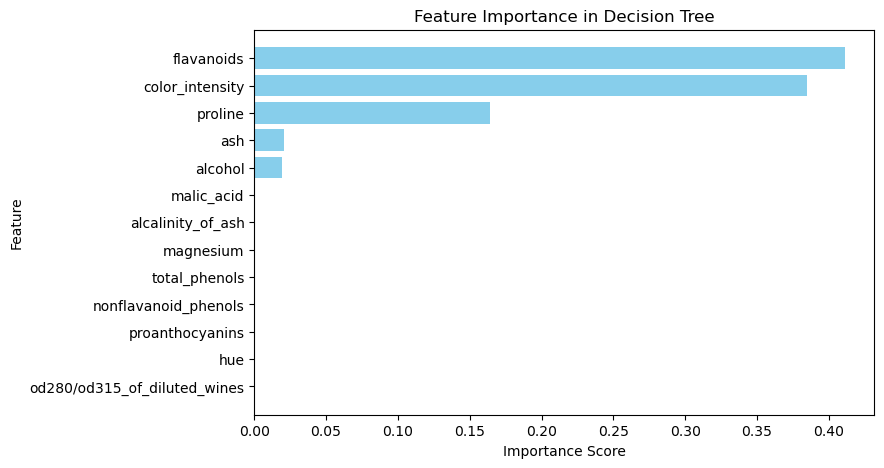

In [33]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

feature_names = wine.feature_names

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Display feature importance scores
feature_importances = clf.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print feature importance scores
print(importance_df)

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
Q26 Write a Python program to train a Decision Tree Regressor with max_depth=5 and compare its performance 
    with an unrestricted tree

Decision Tree (max_depth=5): MSE = 0.5245, R^2 = 0.5997
Decision Tree (unrestricted): MSE = 0.4952, R^2 = 0.6221


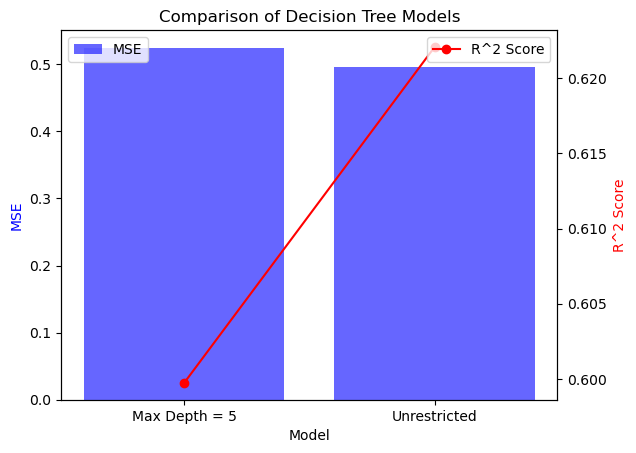

In [36]:
# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Regressor with max_depth=5
dt_reg_limited = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg_limited.fit(X_train, y_train)

# Train an unrestricted Decision Tree Regressor
dt_reg_unrestricted = DecisionTreeRegressor(random_state=42)
dt_reg_unrestricted.fit(X_train, y_train)

# Predictions
y_pred_limited = dt_reg_limited.predict(X_test)
y_pred_unrestricted = dt_reg_unrestricted.predict(X_test)

# Evaluate models
mse_limited = mean_squared_error(y_test, y_pred_limited)
r2_limited = r2_score(y_test, y_pred_limited)

mse_unrestricted = mean_squared_error(y_test, y_pred_unrestricted)
r2_unrestricted = r2_score(y_test, y_pred_unrestricted)

# Print results
print(f"Decision Tree (max_depth=5): MSE = {mse_limited:.4f}, R^2 = {r2_limited:.4f}")
print(f"Decision Tree (unrestricted): MSE = {mse_unrestricted:.4f}, R^2 = {r2_unrestricted:.4f}")

# Visualizing the comparison
labels = ['Max Depth = 5', 'Unrestricted']
mse_values = [mse_limited, mse_unrestricted]
r2_values = [r2_limited, r2_unrestricted]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(labels, mse_values, color='b', alpha=0.6, label='MSE')
ax2.plot(labels, r2_values, color='r', marker='o', label='R^2 Score')

ax1.set_xlabel("Model")
ax1.set_ylabel("MSE", color='b')
ax2.set_ylabel("R^2 Score", color='r')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title("Comparison of Decision Tree Models")
plt.show()

Q27 Write a Python program to train a Decision Tree Classifier, apply Cost Complexity Pruning (CCP), and 
    visualize its effect on accuracy

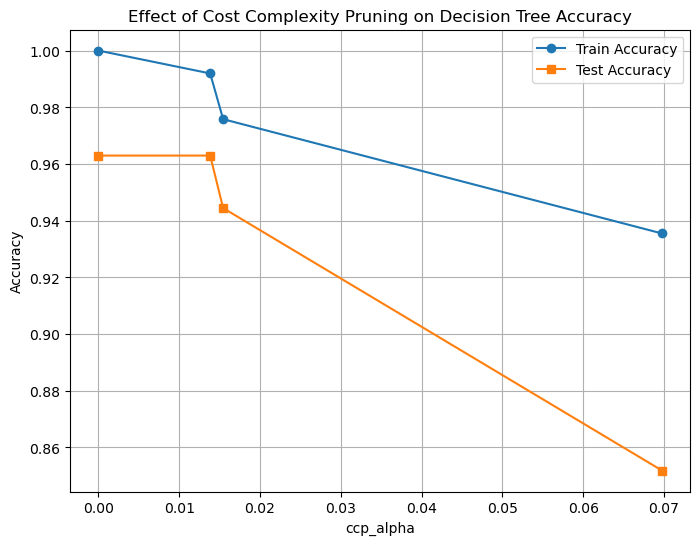

In [38]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Decision Tree Classifier without pruning
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Get cost complexity pruning path
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # Exclude the maximum alpha (prunes all leaves)

train_scores = []
test_scores = []

# Train and evaluate models with different ccp_alpha values
for ccp_alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt_pruned.fit(X_train, y_train)
    
    y_train_pred = dt_pruned.predict(X_train)
    y_test_pred = dt_pruned.predict(X_test)
    
    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

# Plot accuracy vs. ccp_alpha
plt.figure(figsize=(8, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy')
plt.plot(ccp_alphas, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Effect of Cost Complexity Pruning on Decision Tree Accuracy')
plt.legend()
plt.grid()
plt.show()


Q28 Write a Python program to train a Decision Tree Classifier and evaluate its performance using Precision, 
    Recall, and F1-Score

In [48]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model performance
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# Print the evaluation metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Precision: 0.96
Recall: 0.93
F1-Score: 0.94


Q29 Write a Python program to train a Decision Tree Classifier and visualize the confusion matrix using seaborn

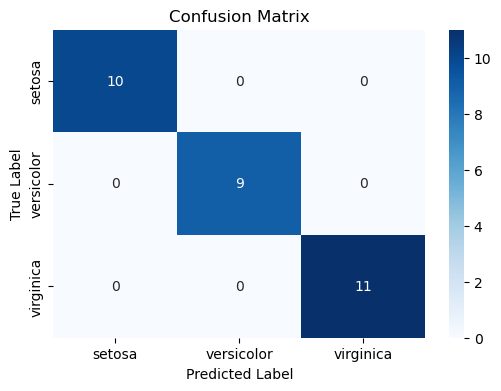

Accuracy: 1.00


In [61]:
# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Decision Tree Classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels= iris.target_names, yticklabels= iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Q30 Write a Python program to train a Decision Tree Classifier and use GridSearchCV to find the optimal values 
    for max_depth and min_samples_split

In [59]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
dt = DecisionTreeClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# Perform GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Evaluate on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")

Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9224
Test Set Accuracy: 0.9444
